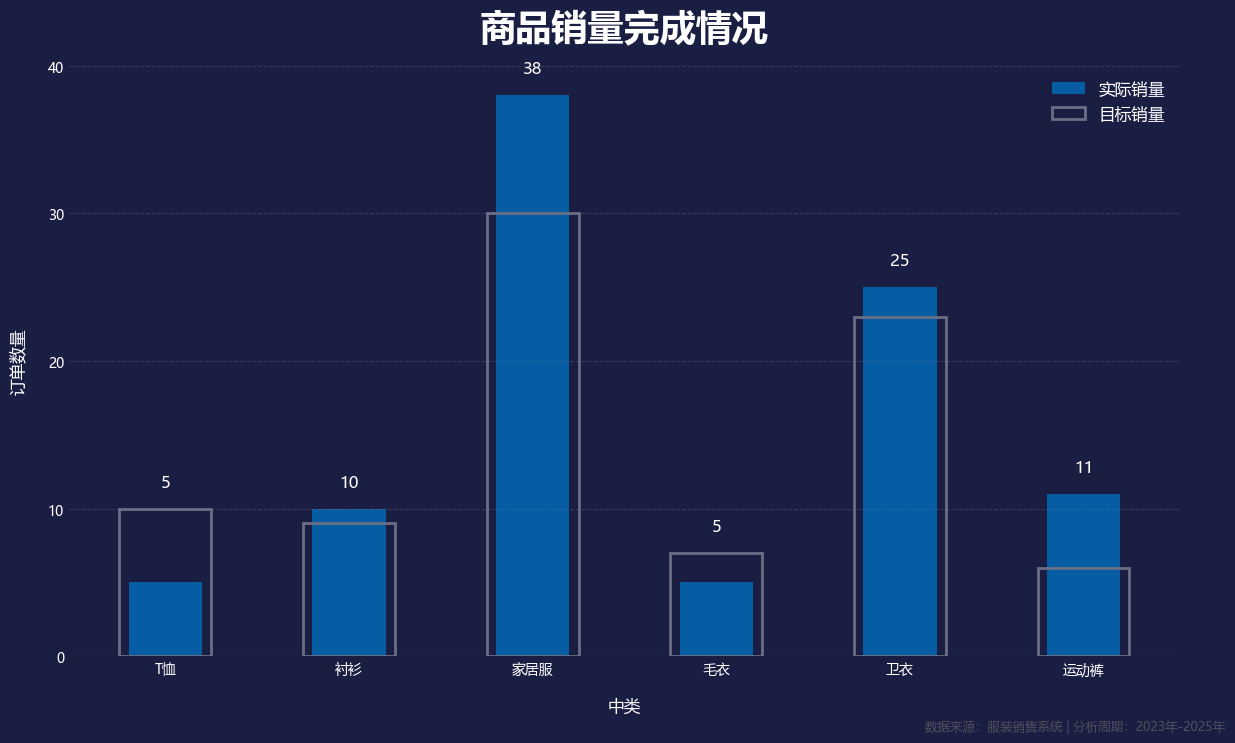

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取新的数据文件
    df = pd.read_csv("../../数据生成/spu_manages_feishu.csv", encoding='utf-8-sig')
    
    # 验证必需字段
    required_columns = ['中类']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    
    # 筛选所需的中类数据
    target_categories = ['T恤', '衬衫', '家居服', '毛衣', '卫衣', '运动裤']
    df = df[df['中类'].isin(target_categories)]
    
    # 检查数据完整性
    if df.empty:
        raise ValueError("过滤后的订单数据为空")
    
    # 定义目标销量
    target_sales = {
        'T恤': 10,
        '衬衫': 9,
        '家居服': 30,
        '毛衣': 7,
        '卫衣': 23,
        '运动裤': 6
    }
    
    # 图表设置
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深色背景
    ax.set_facecolor('#1A1E43')
    
    # 隐藏坐标轴边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 中类的计数
    category_colors = dict(zip(target_categories, ['#016dbc'] * len(target_categories)))
    
    # 绘制各中类的订单总数
    category_counts = df['中类'].value_counts().reindex(target_categories, fill_value=0)
    
    # 绘制实际销量
    ax.bar(category_counts.index, category_counts.values, color='#016dbc', label='实际销量', alpha=0.8, width=0.4, align='center')
    
    # 绘制目标销量
    ax.bar(target_sales.keys(), target_sales.values(), color='none', edgecolor='#6b6e85', linewidth=2, label='目标销量', width=0.5, align='center')

    # 添加标题和标签
    plt.title("商品销量完成情况", fontsize=26, fontweight="bold", color="#ffffff", pad=20)
    plt.xlabel("中类", fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel("订单数量", fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加数据来源说明
    plt.figtext(
        0.9, 0.03,
        '数据来源：服装销售系统 | 分析周期：2023年-2025年',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 设定X轴刻度和标签
    ax.set_xticks(range(len(target_categories)))
    ax.set_xticklabels(target_categories, ha='center', color='#ffffff')
    
    # 隐藏刻度线
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=0)
    ax.xaxis.set_tick_params(colors='#ffffff')
    ax.yaxis.set_tick_params(colors='#ffffff')
    
    # 添加数据标签
    for index, (actual, target) in enumerate(zip(category_counts.values, target_sales.values())):
        # 判断实际销量是否小于目标销量
        if actual < target:
            # 标签在目标销量柱体上方
            ax.text(index, target + 1.5, f'{actual}', color='white', ha='center', fontsize=12)
        else:
            # 标签在实际销量柱体上方
            ax.text(index, actual + 1.5, f'{actual}', color='white', ha='center', fontsize=12)
    
    # 图例
    ax.legend(facecolor='#1A1E43', edgecolor='none', fontsize=12, loc='upper right', labelcolor='white')
    
    # 添加网格线
    ax.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax.grid(axis='x', visible=False)
    
    # 设定Y轴刻度和标签
    ax.set_yticks(np.arange(0, category_counts.max()+10, 10))
    
    # 调整布局
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    # 保存图表
    plt.savefig(
        "商品销量完成情况.png",
        dpi=300,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()
    )
    
    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **T恤**：
  - 目标销量：10
  - 实际销量：5
  - 完成率：50%，表明T恤类别未达到销售目标的一半，可能需要加强市场推广或调整产品策略。

- **衬衫**：
  - 目标销量：9
  - 实际销量：10
  - 完成率：111.1%，显示出衬衫类别略超销售目标，表明该类别市场需求良好或销售策略有效。

- **家居服**：
  - 目标销量：30
  - 实际销量：38
  - 完成率：126.7%，表明家居服类别超额完成了销售目标，可能反映了该类别的高市场需求或有效的营销活动。

- **毛衣**：
  - 目标销量：7
  - 实际销量：5
  - 完成率：71.4%，毛衣类别未达到销售目标，可能需要进一步分析原因并采取措施提高销量。

- **卫衣**：
  - 目标销量：23
  - 实际销量：25
  - 完成率：108.7%，卫衣类别略超额完成销售目标，显示出良好的市场接受度。

- **运动裤**：
  - 目标销量：6
  - 实际销量：11
  - 完成率：183.3%，运动裤类别显著超出销售目标，表明该类别可能具有较高的市场潜力。


# 结论

从商品销量完成情况来看，家居服和运动裤类别表现突出，超额完成了销售目标。衬衫和卫衣类别也达到了销售目标，而T恤和毛衣类别未达到预期目标，需要进一步分析原因并调整策略。